# XGBoost 1200 patients – Validation-based threshold selection

Quy trình thực nghiệm:

1. **Train model** chỉ bằng tập Training; Validation dùng để theo dõi và lựa chọn threshold.
2. **Tìm threshold trên Validation** bằng F1-score; Test không tham gia bước lựa chọn.
3. **Khóa threshold** đã chọn và đánh giá đúng một lần trên fixed Test.

Thiết kế này tránh lựa chọn threshold trực tiếp từ Test.


In [1]:
# Import packages and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, matthews_corrcoef, log_loss,
    brier_score_loss
)

print("Found XGBoost v" + xgboost.__version__)


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/workspaces/todo/.venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/workspaces/todo/.venv/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/workspaces/todo/.venv/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/workspaces/todo/.venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/workspaces/todo/.venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 668, in get
    value = self._validate(obj, default)
  File "/workspaces/todo/.venv/lib/python3.9/s

Found XGBoost v2.1.4


In [2]:
# Experiment configuration
datasetPath = "dataset/1200p/glcm/kernel5/"
fixedTestPath = "dataset/1200p/glcm/kernel5/dataset.test.csv"

# Threshold search is performed ONLY on Validation.
threshold_grid = np.round(np.arange(0.50, 0.951, 0.01), 2)

# Optional finer search can be enabled after inspecting Validation results.
# Example: threshold_grid = np.round(np.arange(0.86, 0.941, 0.01), 2)


## Bước 1 – Train model


In [3]:
# Load patient-separated Train / Validation / fixed Test datasets
train_data = pd.read_csv(f"{datasetPath}dataset.train.csv")
validation_data = pd.read_csv(f"{datasetPath}dataset.validation.csv")
test_data = pd.read_csv(fixedTestPath)

print("Train shape:", train_data.shape)
print("Validation shape:", validation_data.shape)
print("Test shape:", test_data.shape)

print("\nTrain labels:\n", train_data["label"].value_counts().sort_index())
print("\nValidation labels:\n", validation_data["label"].value_counts().sort_index())
print("\nTest labels:\n", test_data["label"].value_counts().sort_index())


Train shape: (939457, 25)
Validation shape: (129946, 25)
Test shape: (261183, 25)

Train labels:
 0    879011
1     60446
Name: label, dtype: int64

Validation labels:
 0    121958
1      7988
Name: label, dtype: int64

Test labels:
 0    242793
1     18390
Name: label, dtype: int64


In [4]:
# Build a common feature list and verify schema consistency
feature_cols = [
    col for col in train_data.columns
    if col not in ["label", "sample_weight"]
]

missing_val = sorted(set(feature_cols) - set(validation_data.columns))
missing_test = sorted(set(feature_cols) - set(test_data.columns))
if missing_val or missing_test:
    raise ValueError(
        f"Feature mismatch. Missing in Validation={missing_val}; Missing in Test={missing_test}"
    )

X_train = train_data[feature_cols]
y_train = train_data["label"].astype(int)
X_val = validation_data[feature_cols]
y_val = validation_data["label"].astype(int)
X_test = test_data[feature_cols]
y_test = test_data["label"].astype(int)

# Calculate class weights from TRAINING labels only.
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight = dict(zip(classes, weights))
train_weight = y_train.map(class_weight).to_numpy()
val_weight = y_val.map(class_weight).to_numpy()

print("Number of features:", len(feature_cols))
print("Class weights computed from Training only:", class_weight)


Number of features: 24
Class weights computed from Training only: {0: 0.5343829599402056, 1: 7.771043576084439}


In [5]:
# Train XGBoost baseline model
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric=["logloss", "auc", "aucpr"],
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    sample_weight=train_weight,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    sample_weight_eval_set=[train_weight, val_weight],
    verbose=False
)

print("Training completed.")


Training completed.


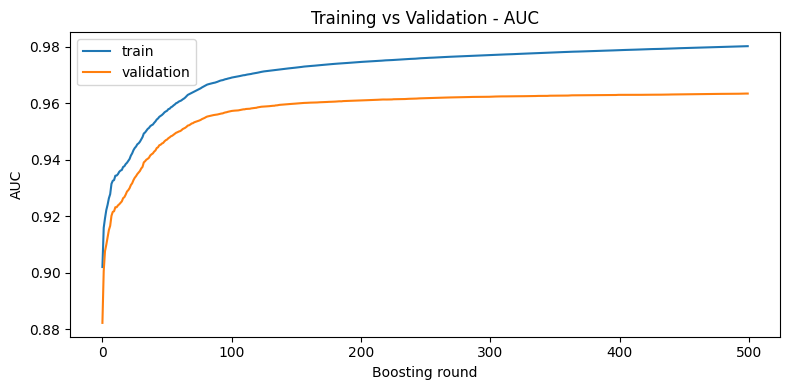

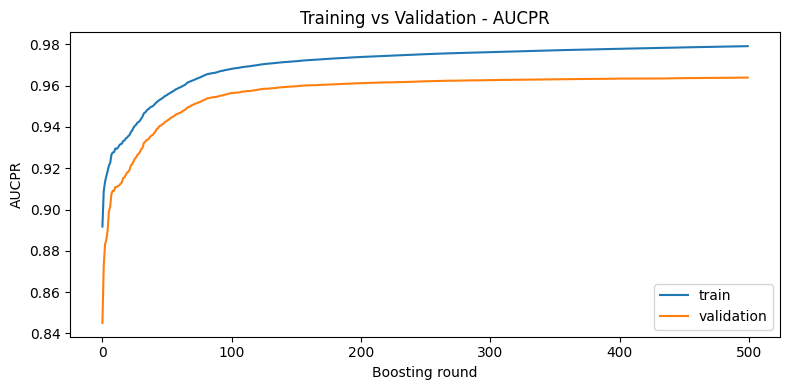

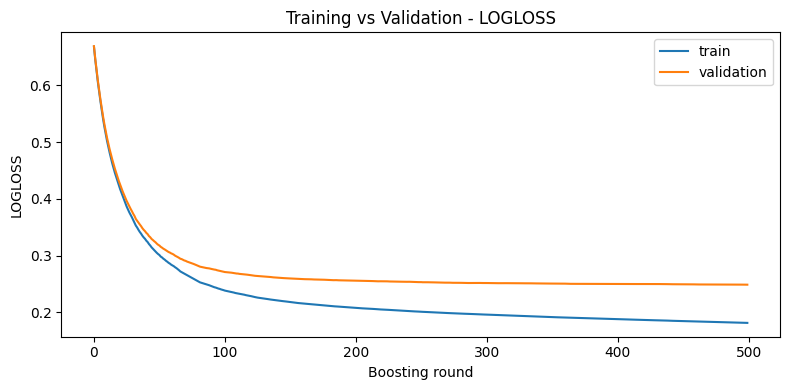

In [6]:
# Optional training curves
results = model.evals_result()

for metric_name in ["auc", "aucpr", "logloss"]:
    if metric_name in results["validation_0"]:
        plt.figure(figsize=(8, 4))
        plt.plot(results["validation_0"][metric_name], label="train")
        plt.plot(results["validation_1"][metric_name], label="validation")
        plt.xlabel("Boosting round")
        plt.ylabel(metric_name.upper())
        plt.title(f"Training vs Validation - {metric_name.upper()}")
        plt.legend()
        plt.tight_layout()
        plt.show()


## Bước 2 – Tìm threshold bằng Validation

Threshold được lựa chọn **chỉ từ Validation**. Test chưa được sử dụng ở bước này. Tiêu chí chính là F1-score. Bảng cũng báo cáo Precision, Recall và MCC để kiểm tra trade-off.


In [7]:
# Predict probabilities on Validation ONCE
val_probs = model.predict_proba(X_val)[:, 1]

validation_rows = []
for threshold in threshold_grid:
    val_pred = (val_probs >= threshold).astype(int)
    cm = confusion_matrix(y_val, val_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    validation_rows.append({
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_val, val_pred),
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_val, val_pred),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    })

threshold_results = pd.DataFrame(validation_rows)

# ROC-AUC and PR-AUC are threshold-independent and are reported once.
validation_roc_auc = roc_auc_score(y_val, val_probs)
validation_pr_auc = average_precision_score(y_val, val_probs)

print(f"Validation ROC-AUC: {validation_roc_auc:.4f}")
print(f"Validation PR-AUC:  {validation_pr_auc:.4f}")
threshold_results


Validation ROC-AUC: 0.9635
Validation PR-AUC:  0.7673


,threshold,accuracy,precision,recall,f1,mcc,tn,fp,fn,tp
0,0.50,0.890516,0.350262,0.913495,0.506367,0.525362,108422,13536,691,7297
1,0.51,0.892709,0.354908,0.911617,0.510910,0.529000,108722,13236,706,7282
2,0.52,0.895203,0.360353,0.909364,0.516166,0.533193,109064,12894,724,7264
3,0.53,0.897519,0.365572,0.907111,0.521126,0.537125,109383,12575,742,7246
4,0.54,0.899658,0.370520,0.904732,0.525734,0.540721,109680,12278,761,7227
5,0.55,0.901967,0.376076,0.902479,0.530913,0.544852,109998,11960,779,7209
6,0.56,0.904299,0.381903,0.900351,0.536316,0.549209,110318,11640,796,7192
7,0.57,0.906276,0.386944,0.897847,0.540814,0.552694,110595,11363,816,7172
8,0.58,0.908508,0.392894,0.895719,0.546204,0.557049,110902,11056,833,7155
9,0.59,0.910509,0.398415,0.893841,0.551160,0.561073,111177,10781,848,7140


In [8]:
# Select threshold by the highest Validation F1.
# Tie-break rule: if F1 is numerically tied, prefer higher Recall, then lower threshold.
ranked_thresholds = threshold_results.sort_values(
    by=["f1", "recall", "threshold"],
    ascending=[False, False, True]
).reset_index(drop=True)

best_row = ranked_thresholds.iloc[0]
locked_threshold = float(best_row["threshold"])

print("Selected threshold from Validation ONLY")
print(f"locked_threshold = {locked_threshold:.2f}")
print(f"Validation F1        = {best_row['f1']:.4f}")
print(f"Validation Precision = {best_row['precision']:.4f}")
print(f"Validation Recall    = {best_row['recall']:.4f}")
print(f"Validation MCC       = {best_row['mcc']:.4f}")

# Save the complete Validation threshold sweep for thesis reporting/audit.
threshold_results.to_csv(
    "validation_threshold_search_1200p.csv",
    index=False
)


Selected threshold from Validation ONLY
locked_threshold = 0.89
Validation F1        = 0.7048
Validation Precision = 0.7039
Validation Recall    = 0.7058
Validation MCC       = 0.6855


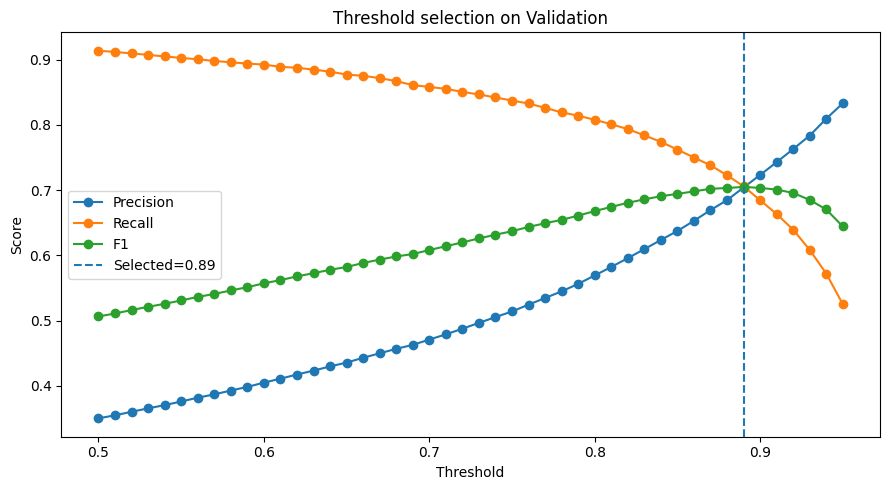

In [9]:
# Visualize Validation threshold trade-off
plt.figure(figsize=(9, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], marker="o", label="F1")
plt.axvline(locked_threshold, linestyle="--", label=f"Selected={locked_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold selection on Validation")
plt.legend()
plt.tight_layout()
plt.show()


## Bước 3 – Khóa threshold rồi chạy Test

Từ cell này trở đi, `locked_threshold` không được điều chỉnh theo kết quả Test. Test chỉ được dùng để đánh giá cuối cùng.


In [10]:
# FINAL TEST EVALUATION with the locked Validation threshold
test_probs = model.predict_proba(X_test)[:, 1]
y_test_pred = (test_probs >= locked_threshold).astype(int)
y_true = y_test.to_numpy()

final_metrics = {
    "threshold": locked_threshold,
    "accuracy": accuracy_score(y_true, y_test_pred),
    "precision": precision_score(y_true, y_test_pred, zero_division=0),
    "recall": recall_score(y_true, y_test_pred, zero_division=0),
    "f1": f1_score(y_true, y_test_pred, zero_division=0),
    "mcc": matthews_corrcoef(y_true, y_test_pred),
    "roc_auc": roc_auc_score(y_true, test_probs),
    "pr_auc": average_precision_score(y_true, test_probs),
    "log_loss": log_loss(y_true, test_probs, labels=[0, 1]),
    "brier_score": brier_score_loss(y_true, test_probs),
}

cm = confusion_matrix(y_true, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
final_metrics.update({
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
})

print("FINAL TEST metrics (threshold locked from Validation):")
for name, value in final_metrics.items():
    if name in ["tn", "fp", "fn", "tp"]:
        print(f"{name}: {value}")
    else:
        print(f"{name}: {value:.4f}")

print("\nConfusion matrix [TN FP; FN TP]:\n", cm)
print("\nClassification report:\n")
print(classification_report(y_true, y_test_pred, digits=4, zero_division=0))

# Save exactly one row of final Test results.
pd.DataFrame([final_metrics]).to_csv(
    "final_test_metrics_1200p_validation_threshold.csv",
    index=False
)


FINAL TEST metrics (threshold locked from Validation):
threshold: 0.8900
accuracy: 0.9473
precision: 0.6071
recall: 0.7136
f1: 0.6561
mcc: 0.6302
roc_auc: 0.9408
pr_auc: 0.7278
log_loss: 0.3882
brier_score: 0.1249
tn: 234301
fp: 8492
fn: 5266
tp: 13124

Confusion matrix [TN FP; FN TP]:
 [[234301   8492]
 [  5266  13124]]

Classification report:

              precision    recall  f1-score   support

           0     0.9780    0.9650    0.9715    242793
           1     0.6071    0.7136    0.6561     18390

    accuracy                         0.9473    261183
   macro avg     0.7926    0.8393    0.8138    261183
weighted avg     0.9519    0.9473    0.9493    261183



## Feature importance (phân tích bổ sung)


JointAverage          0.152818
Correlation           0.126540
DifferenceVariance    0.107254
SumAverage            0.090785
Autocorrelation       0.076547
Imc1                  0.049655
Idn                   0.046118
InverseVariance       0.040568
Contrast              0.039090
DifferenceEntropy     0.037910
Idmn                  0.035122
ClusterShade          0.025602
MCC                   0.024608
MaximumProbability    0.022200
DifferenceAverage     0.021437
Id                    0.018901
SumEntropy            0.016718
Idm                   0.013157
Imc2                  0.011815
JointEnergy           0.010481
dtype: float32


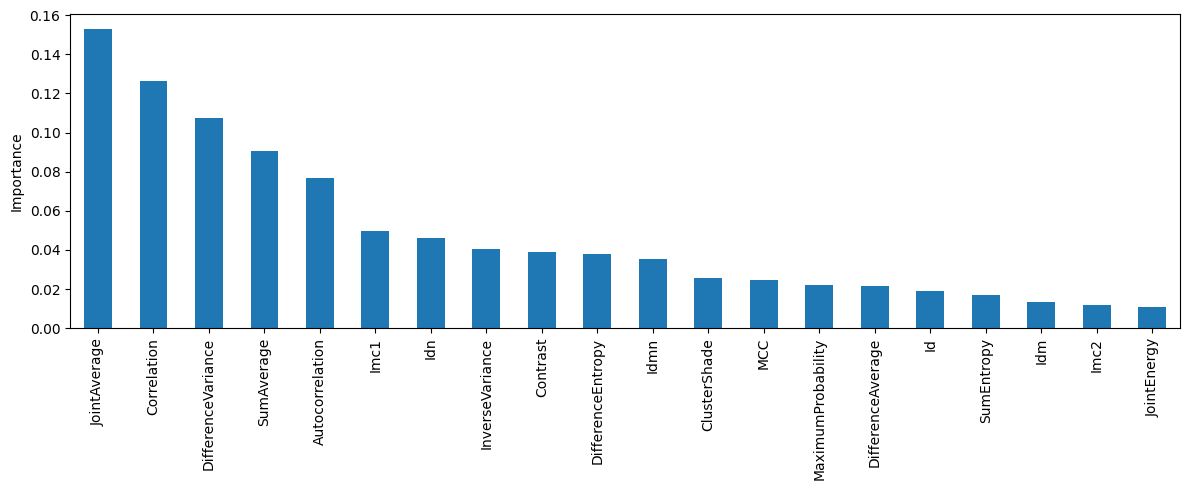

In [11]:
feature_importance = (
    pd.Series(model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)

print(feature_importance.head(20))
feature_importance.head(20).plot.bar(figsize=(12, 5))
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


### Ghi chú phương pháp

- Class weight được tính **chỉ từ Training**.
- Threshold được chọn **chỉ từ Validation**.
- Test không được dùng để chọn threshold hoặc siêu tham số.
- ROC-AUC và PR-AUC được tính từ xác suất dự đoán nên không phụ thuộc threshold.
- Notebook này chưa thực hiện hyperparameter tuning hoặc early stopping; cấu hình XGBoost vẫn là cấu hình baseline hiện tại.
